# Final Homework — Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Course:** Introduction to Data Science  
**Dataset:** Data-center energy consumption and outside weather measurements  
**Student:** Itamar Perez  
**Student ID:** _fill in before submission_

> **Methodology box:** This notebook uses the same compact data-center working sample from the previous assignments, but the task is now unsupervised. No anomaly labels are used. The analysis investigates hidden structure, dimensionality reduction, clustering, and multi-dimensional anomaly detection.


## 1. Assignment Objective and Methodological Plan

The goal is to explore the geometry and abnormal behavior of a real-world tabular sensor dataset without using supervised labels. The notebook follows these stages:

1. Dataset selection and context
2. Exploratory data analysis
3. PCA and dimensionality reduction
4. Sample clustering using K-Means, DBSCAN, and Hierarchical Clustering
5. Feature-space clustering using the transpose of the data matrix
6. Multi-dimensional anomaly detection using Z-score, Isolation Forest, and Local Outlier Factor
7. Comparison, critical reflection, ethical considerations, and final conclusions

> **Interpretation box:** Because this is an unsupervised problem, there is no ground truth saying which cluster is correct or which observation is truly anomalous. The analysis therefore emphasizes method assumptions, agreement between methods, and operational interpretation rather than claiming that one algorithm reveals the absolute truth.


In [1]:
# Core libraries
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import skew, kurtosis

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


## 2. Dataset Selection and Real-World Context

The selected dataset is a compact working sample from a data-center energy and outside weather dataset. It contains chronological sensor measurements related to power usage, cooling behavior, data-center efficiency, and outside environmental conditions.

The compact sample is appropriate for this assignment because it contains more than 1,000 rows, more than 8 candidate features, mostly numerical variables, and no pre-labeled anomaly column.

> **Dataset box:** The dataset was likely collected for operational monitoring of a data-center environment. Such measurements are useful for understanding energy efficiency, cooling demand, and how outside weather may affect infrastructure behavior. The compact sample does not include a manually verified anomaly label, which makes it suitable for unsupervised anomaly detection.


In [2]:
DATA_PATH = Path("data_center_working_sample.csv")

if not DATA_PATH.exists():
    # This fallback helps if the notebook is executed from a parent folder.
    fallback_path = Path("/mnt/data/data_center_working_sample.csv")
    if fallback_path.exists():
        DATA_PATH = fallback_path
    else:
        raise FileNotFoundError("data_center_working_sample.csv was not found.")

raw_df = pd.read_csv(DATA_PATH)

if "ts" in raw_df.columns:
    raw_df["ts"] = pd.to_datetime(raw_df["ts"], errors="coerce", utc=True)

print("Loaded file:", DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head())


Loaded file: data_center_working_sample.csv
Raw shape: (1500, 26)


,tags_power,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day_power,tags_weather,outdoor_air_humidity,outdoor_air_temp,unit,day_weather,hour_of_day,minute_of_day,day_of_week,month,date,is_weekend,total_facility_kw,cooling_to_it_ratio,load_level,pue_category
0,NaN,2016-07-28 08:45:24+00:00,7.47,NaN,0.936,9.06,887.73,2.46,1.034,11.52,28,NaN,63.9,67.4,NaN,28,8,525,Thursday,7,2016-07-28,False,918.24,0.008415,Low,Excellent
1,NaN,2016-07-28 08:46:22+00:00,7.77,NaN,0.936,9.44,885.44,2.46,1.035,11.22,28,NaN,63.9,67.4,NaN,28,8,526,Thursday,7,2016-07-28,False,916.33,0.008775,Low,Excellent
2,NaN,2016-07-28 08:47:22+00:00,7.77,NaN,0.941,9.34,885.08,2.44,1.035,11.22,28,NaN,63.9,67.3,NaN,28,8,527,Thursday,7,2016-07-28,False,915.85,0.008779,Low,Excellent
3,NaN,2016-07-28 08:48:22+00:00,7.67,NaN,0.947,10.06,887.15,2.46,1.036,11.72,28,NaN,63.9,67.1,NaN,28,8,528,Thursday,7,2016-07-28,False,919.06,0.008646,Low,Excellent
4,NaN,2016-07-28 08:49:23+00:00,7.67,NaN,0.950,10.01,885.13,2.44,1.036,11.72,28,NaN,63.9,67.0,NaN,28,8,529,Thursday,7,2016-07-28,False,916.97,0.008665,Low,Excellent


### Feature Meaning

The analysis focuses on the main numerical engineering and environmental features. Some columns in the compact file are metadata, categorical, or derived labels from previous assignments; they are not used as direct anomaly labels.


In [3]:
feature_description = pd.DataFrame({
    "feature": [
        "cooling_kw", "ere", "hvac_kw", "it_power_kw", "plug_and_light_kw",
        "pue", "pump_kw", "outdoor_air_humidity", "outdoor_air_temp",
        "hour_of_day", "minute_of_day", "total_facility_kw", "cooling_to_it_ratio"
    ],
    "meaning": [
        "Cooling power demand in kW",
        "Energy reuse effectiveness measure",
        "HVAC power consumption in kW",
        "IT equipment power consumption in kW",
        "Plug and lighting power consumption in kW",
        "Power Usage Effectiveness, a data-center efficiency measure",
        "Pump power consumption in kW",
        "Outside air humidity percentage",
        "Outside air temperature measurement",
        "Hour extracted from timestamp",
        "Minute of day extracted from timestamp",
        "Engineered total facility power from available power components",
        "Engineered ratio of cooling power to IT power"
    ],
    "reason_for_use": [
        "Core cooling behavior and likely anomaly signal",
        "Efficiency-related behavior",
        "Cooling-support subsystem behavior",
        "Primary data-center load driver",
        "Auxiliary electrical load behavior",
        "Global efficiency indicator",
        "Cooling-system support behavior",
        "External weather driver",
        "External weather driver",
        "Daily temporal structure",
        "More detailed daily temporal structure",
        "Aggregate power behavior and redundancy check",
        "Normalized cooling behavior relative to IT load"
    ]
})

display(feature_description)


,feature,meaning,reason_for_use
0,cooling_kw,Cooling power demand in kW,Core cooling behavior and likely anomaly signal
1,ere,Energy reuse effectiveness measure,Efficiency-related behavior
2,hvac_kw,HVAC power consumption in kW,Cooling-support subsystem behavior
3,it_power_kw,IT equipment power consumption in kW,Primary data-center load driver
4,plug_and_light_kw,Plug and lighting power consumption in kW,Auxiliary electrical load behavior
5,pue,"Power Usage Effectiveness, a data-center effic...",Global efficiency indicator
6,pump_kw,Pump power consumption in kW,Cooling-system support behavior
7,outdoor_air_humidity,Outside air humidity percentage,External weather driver
8,outdoor_air_temp,Outside air temperature measurement,External weather driver
9,hour_of_day,Hour extracted from timestamp,Daily temporal structure


## 3. Structural EDA

This section checks the number of observations, number of columns, missing values, data types, statistical summaries, and the correlation matrix.


In [4]:
structural_summary = pd.DataFrame({
    "item": ["number_of_rows", "number_of_columns", "time_start", "time_end", "duplicate_rows"],
    "value": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df["ts"].min() if "ts" in raw_df.columns else "not available",
        raw_df["ts"].max() if "ts" in raw_df.columns else "not available",
        raw_df.duplicated().sum(),
    ]
})

display(structural_summary)

missing_summary = (
    raw_df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percentage=lambda x: (x["missing_count"] / len(raw_df) * 100).round(2))
    .sort_values("missing_percentage", ascending=False)
)

display(missing_summary)

dtype_summary = raw_df.dtypes.astype(str).to_frame("dtype")
display(dtype_summary)


,item,value
0,number_of_rows,1500
1,number_of_columns,26
2,time_start,2016-07-28 08:45:24+00:00
3,time_end,2016-07-29 09:44:21+00:00
4,duplicate_rows,0


,missing_count,missing_percentage
tags_power,1500,100.0
energy_reuse,1500,100.0
unit,1500,100.0
tags_weather,1500,100.0
ts,0,0.0
cooling_kw,0,0.0
it_power_kw,0,0.0
plug_and_light_kw,0,0.0
ere,0,0.0
hvac_kw,0,0.0


,dtype
tags_power,float64
ts,"datetime64[ns, UTC]"
cooling_kw,float64
energy_reuse,float64
ere,float64
hvac_kw,float64
it_power_kw,float64
plug_and_light_kw,float64
pue,float64
pump_kw,float64


In [5]:
MODEL_FEATURES = [
    "cooling_kw",
    "ere",
    "hvac_kw",
    "it_power_kw",
    "plug_and_light_kw",
    "pue",
    "pump_kw",
    "outdoor_air_humidity",
    "outdoor_air_temp",
    "hour_of_day",
    "minute_of_day",
    "total_facility_kw",
    "cooling_to_it_ratio",
]

missing_features = [feature for feature in MODEL_FEATURES if feature not in raw_df.columns]
if missing_features:
    raise ValueError(f"Missing required modeling features: {missing_features}")

analysis_df = raw_df[MODEL_FEATURES].copy()
for feature in MODEL_FEATURES:
    analysis_df[feature] = pd.to_numeric(analysis_df[feature], errors="coerce")

analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

# Median imputation is used only for robustness. In this sample, the selected features are expected to be complete.
analysis_df = analysis_df.fillna(analysis_df.median(numeric_only=True))

print("Analysis shape:", analysis_df.shape)
print("Missing values after preprocessing:", int(analysis_df.isna().sum().sum()))
display(analysis_df.describe().T)


Analysis shape: (1500, 13)
Missing values after preprocessing: 0


,count,mean,std,min,25%,50%,75%,max
cooling_kw,1500.0,12.242600,4.274736,4.870000,8.770000,12.170000,14.970000,19.270000
ere,1500.0,0.969907,0.022114,0.897000,0.953000,0.974000,0.989000,1.005000
hvac_kw,1500.0,8.847607,0.869589,5.710000,8.390000,8.940000,9.420000,11.270000
it_power_kw,1500.0,904.703500,19.789070,861.330000,883.772500,912.085000,922.652500,933.330000
plug_and_light_kw,1500.0,3.908727,2.150793,2.410000,2.440000,2.460000,6.460000,8.490000
pue,1500.0,1.040306,0.005680,1.029000,1.036000,1.041000,1.045000,1.054000
pump_kw,1500.0,11.503927,0.335226,10.520000,11.230000,11.520000,11.720000,12.420000
outdoor_air_humidity,1500.0,61.259200,14.723567,43.700000,47.900000,57.350000,80.500000,85.100000
outdoor_air_temp,1500.0,71.357267,7.291816,61.200000,64.275000,72.500000,78.600000,82.700000
hour_of_day,1500.0,11.390000,6.806525,0.000000,6.000000,11.000000,17.000000,23.000000


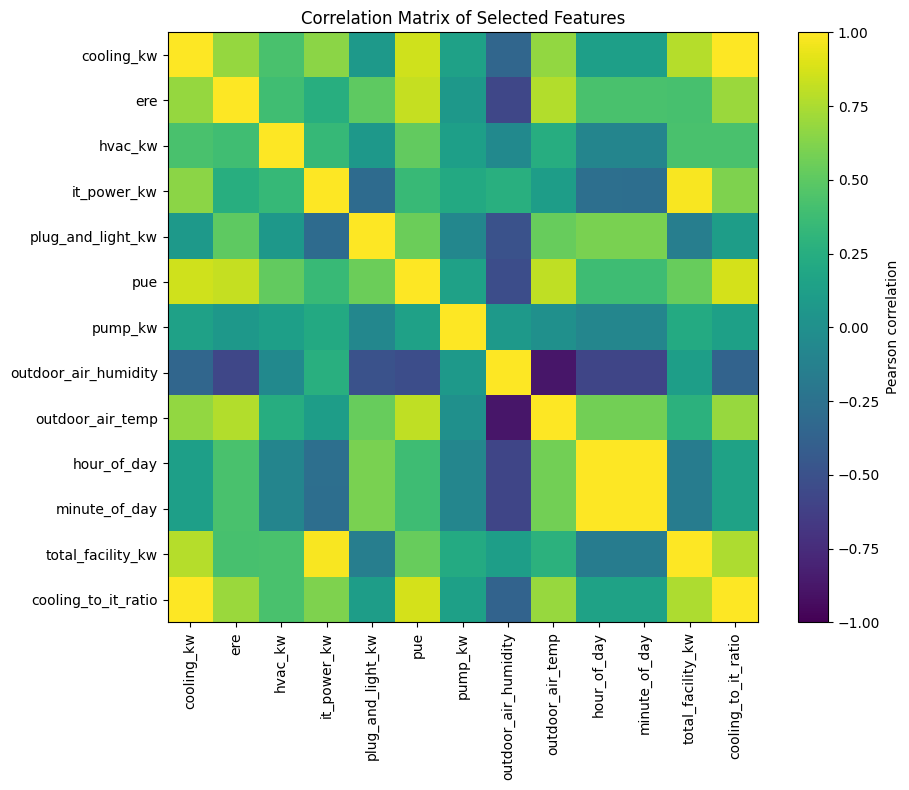

,feature_1,feature_2,correlation
2,cooling_kw,cooling_to_it_ratio,0.999
9,hour_of_day,minute_of_day,0.999
5,it_power_kw,total_facility_kw,0.978
8,outdoor_air_humidity,outdoor_air_temp,-0.878
7,pue,cooling_to_it_ratio,0.874
0,cooling_kw,pue,0.857
3,ere,pue,0.822
6,pue,outdoor_air_temp,0.810
1,cooling_kw,total_facility_kw,0.780
4,ere,outdoor_air_temp,0.770


In [6]:
correlation_matrix = analysis_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.show()

strong_correlations = []
for i, first_feature in enumerate(correlation_matrix.columns):
    for j, second_feature in enumerate(correlation_matrix.columns):
        if j > i:
            corr_value = correlation_matrix.loc[first_feature, second_feature]
            if abs(corr_value) >= 0.75:
                strong_correlations.append({
                    "feature_1": first_feature,
                    "feature_2": second_feature,
                    "correlation": round(float(corr_value), 3)
                })

strong_correlation_df = pd.DataFrame(strong_correlations).sort_values("correlation", key=lambda s: s.abs(), ascending=False)
display(strong_correlation_df)


> **EDA interpretation box:** The selected features are mostly numerical engineering measurements. Strong correlations are expected because data-center subsystems are physically linked: IT load contributes to total facility power, cooling behavior affects efficiency, and weather can influence cooling demand. These correlations create redundancy, which is important for PCA and feature clustering.


## 4. Distribution Analysis

For each major feature, the notebook reports histogram, boxplot, skewness, and kurtosis. Skewness describes asymmetry. Kurtosis describes tail heaviness relative to a normal distribution.


In [7]:
distribution_summary = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "skewness": [skew(analysis_df[feature], nan_policy="omit") for feature in MODEL_FEATURES],
    "kurtosis_fisher": [kurtosis(analysis_df[feature], fisher=True, nan_policy="omit") for feature in MODEL_FEATURES],
}).sort_values("kurtosis_fisher", ascending=False)

display(distribution_summary)


,feature,skewness,kurtosis_fisher
2,hvac_kw,-0.655821,0.838010
6,pump_kw,-0.014639,-0.270756
1,ere,-0.626305,-0.341262
4,plug_and_light_kw,0.944810,-0.902570
5,pue,-0.139418,-1.019570
0,cooling_kw,0.048419,-1.075168
12,cooling_to_it_ratio,0.047290,-1.093612
10,minute_of_day,0.045742,-1.146154
9,hour_of_day,0.045654,-1.150713
11,total_facility_kw,-0.484034,-1.218483


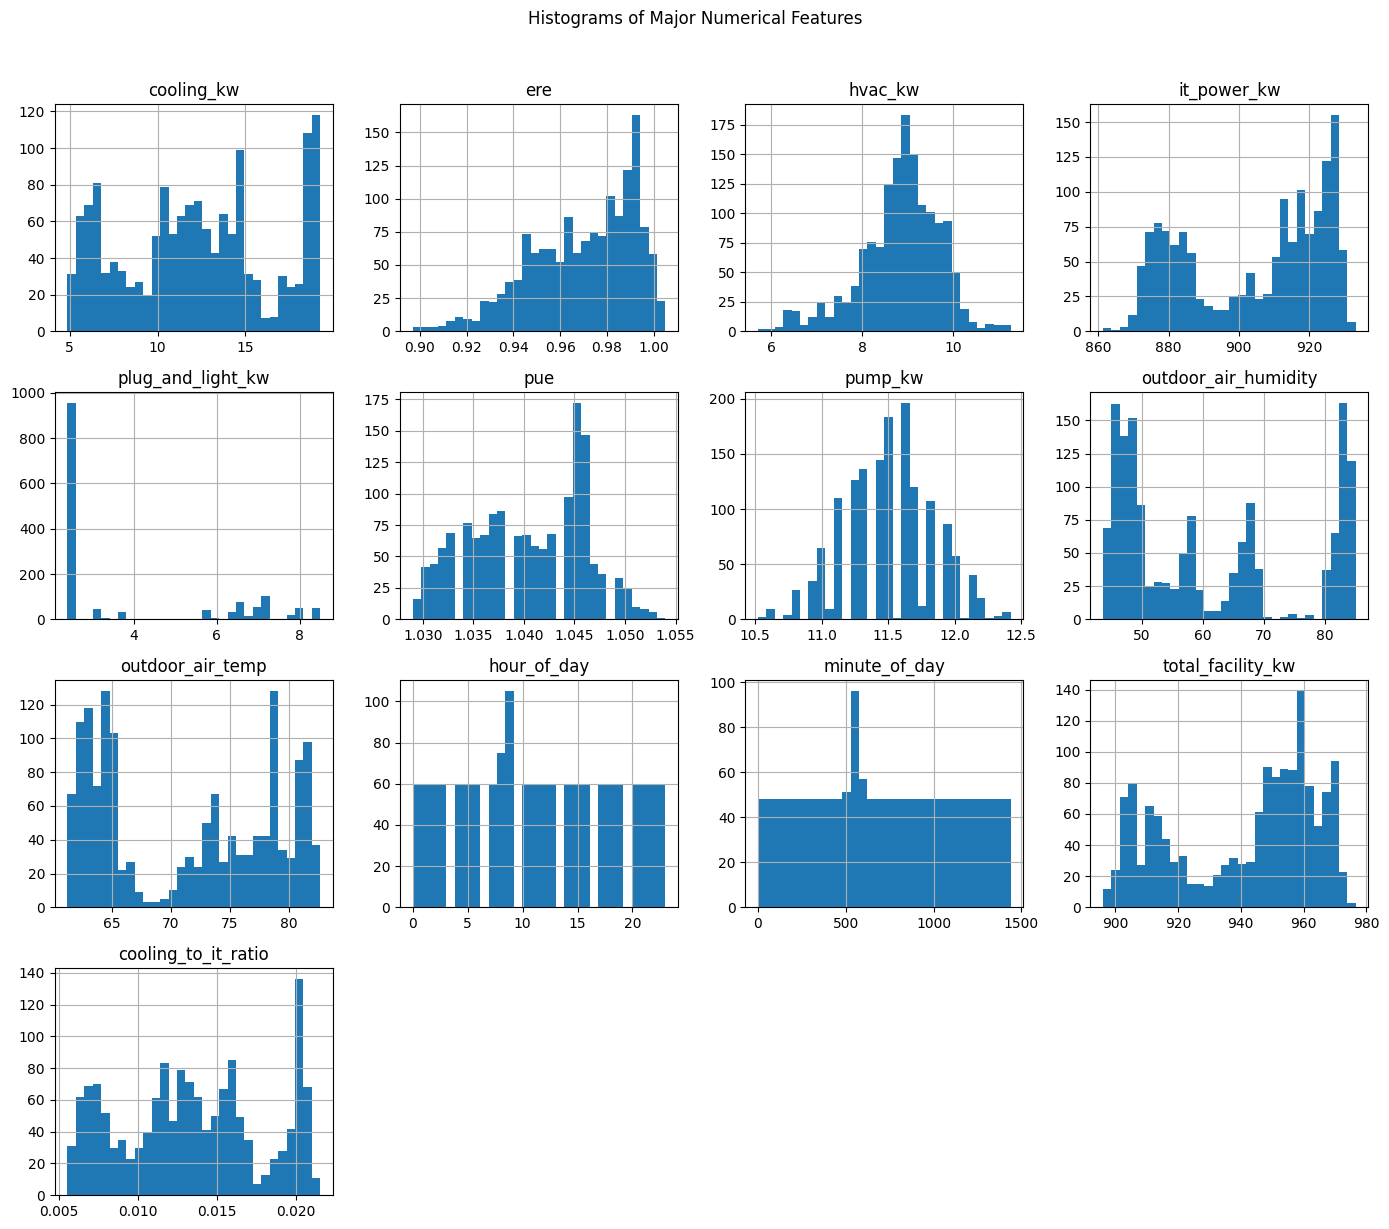

In [8]:
# Histograms for all major numerical features
axes = analysis_df[MODEL_FEATURES].hist(figsize=(14, 12), bins=30)
plt.suptitle("Histograms of Major Numerical Features", y=1.02)
plt.tight_layout()
plt.show()


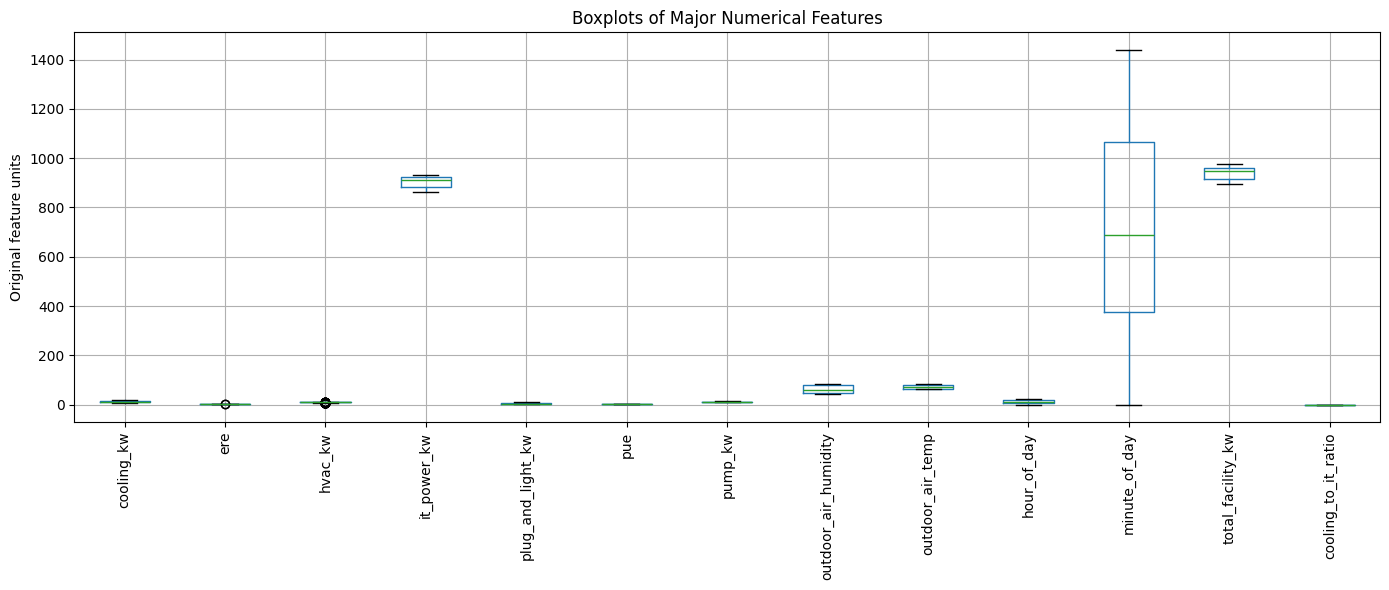

In [9]:
plt.figure(figsize=(14, 6))
analysis_df[MODEL_FEATURES].boxplot(rot=90)
plt.title("Boxplots of Major Numerical Features")
plt.ylabel("Original feature units")
plt.tight_layout()
plt.show()


In [10]:
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_rows = []
for feature in MODEL_FEATURES:
    outlier_rows.append({
        "feature": feature,
        "iqr_outliers": count_iqr_outliers(analysis_df[feature]),
        "iqr_outlier_percentage": round(count_iqr_outliers(analysis_df[feature]) / len(analysis_df) * 100, 2),
        "minimum": analysis_df[feature].min(),
        "maximum": analysis_df[feature].max(),
        "median": analysis_df[feature].median(),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_outliers", ascending=False)
display(outlier_summary)


,feature,iqr_outliers,iqr_outlier_percentage,minimum,maximum,median
2,hvac_kw,59,3.93,5.710000,11.270000,8.940000
1,ere,2,0.13,0.897000,1.005000,0.974000
0,cooling_kw,0,0.00,4.870000,19.270000,12.170000
3,it_power_kw,0,0.00,861.330000,933.330000,912.085000
4,plug_and_light_kw,0,0.00,2.410000,8.490000,2.460000
5,pue,0,0.00,1.029000,1.054000,1.041000
6,pump_kw,0,0.00,10.520000,12.420000,11.520000
7,outdoor_air_humidity,0,0.00,43.700000,85.100000,57.350000
8,outdoor_air_temp,0,0.00,61.200000,82.700000,72.500000
9,hour_of_day,0,0.00,0.000000,23.000000,11.000000


> **Outlier interpretation box:** Extreme values in operational sensor data should not be deleted automatically. A large value may be measurement noise, but it may also represent a legitimate high-load event, a cooling cycle, a transient operating state, or a meaningful anomaly. This is why the notebook treats outlier methods as flags for investigation rather than as automatic deletion rules.


## 5. Scaling and PCA Preparation

PCA, K-Means, DBSCAN, LOF, and distance-based analysis are sensitive to feature scale. Therefore all modeling features are standardized to zero mean and unit variance before applying unsupervised methods.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(analysis_df[MODEL_FEATURES])
scaled_df = pd.DataFrame(X_scaled, columns=MODEL_FEATURES, index=analysis_df.index)

display(scaled_df.describe().T[["mean", "std", "min", "max"]].round(3))


,mean,std,min,max
cooling_kw,-0.0,1.0,-1.725,1.644
ere,-0.0,1.0,-3.298,1.587
hvac_kw,0.0,1.0,-3.609,2.787
it_power_kw,0.0,1.0,-2.193,1.447
plug_and_light_kw,-0.0,1.0,-0.697,2.131
pue,0.0,1.0,-1.991,2.412
pump_kw,-0.0,1.0,-2.936,2.734
outdoor_air_humidity,0.0,1.0,-1.193,1.620
outdoor_air_temp,0.0,1.0,-1.393,1.556
hour_of_day,-0.0,1.0,-1.674,1.706


## 6. Principal Component Analysis (PCA)

PCA finds orthogonal directions that explain the maximum variance in the standardized data. The first principal component explains the largest amount of variance, the second explains the largest remaining variance, and so on.


In [12]:
pca = PCA(random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)

explained_variance_df = pd.DataFrame({
    "principal_component": [f"PC{i+1}" for i in range(len(MODEL_FEATURES))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

display(explained_variance_df)

components_for_80 = int(np.searchsorted(explained_variance_df["cumulative_explained_variance"], 0.80) + 1)
components_for_90 = int(np.searchsorted(explained_variance_df["cumulative_explained_variance"], 0.90) + 1)
components_for_95 = int(np.searchsorted(explained_variance_df["cumulative_explained_variance"], 0.95) + 1)

print("Components needed for at least 80% variance:", components_for_80)
print("Components needed for at least 90% variance:", components_for_90)
print("Components needed for at least 95% variance:", components_for_95)


,principal_component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.449014,0.449014
1,PC2,0.275996,0.725010
2,PC3,0.072958,0.797968
3,PC4,0.068036,0.866004
4,PC5,0.054499,0.920503
5,PC6,0.038986,0.959489
6,PC7,0.020556,0.980045
7,PC8,0.018063,0.998108
8,PC9,0.001695,0.999803
9,PC10,0.000124,0.999927


Components needed for at least 80% variance: 4
Components needed for at least 90% variance: 5
Components needed for at least 95% variance: 6


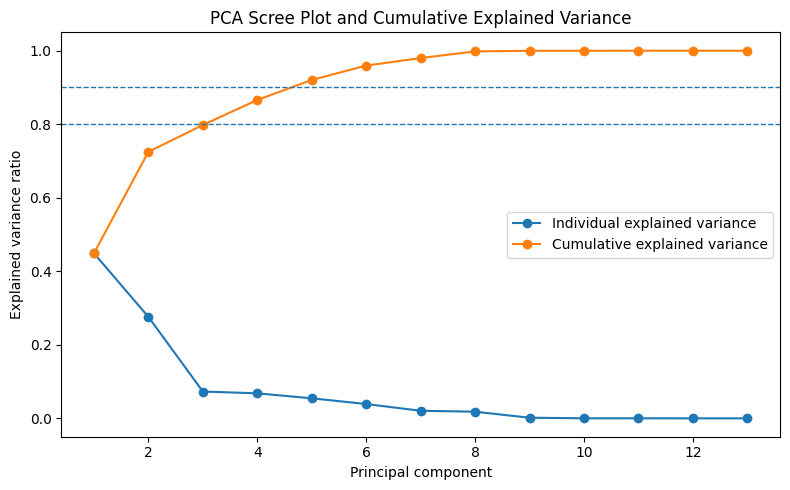

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(MODEL_FEATURES) + 1), pca.explained_variance_ratio_, marker="o", label="Individual explained variance")
plt.plot(range(1, len(MODEL_FEATURES) + 1), np.cumsum(pca.explained_variance_ratio_), marker="o", label="Cumulative explained variance")
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Scree Plot and Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


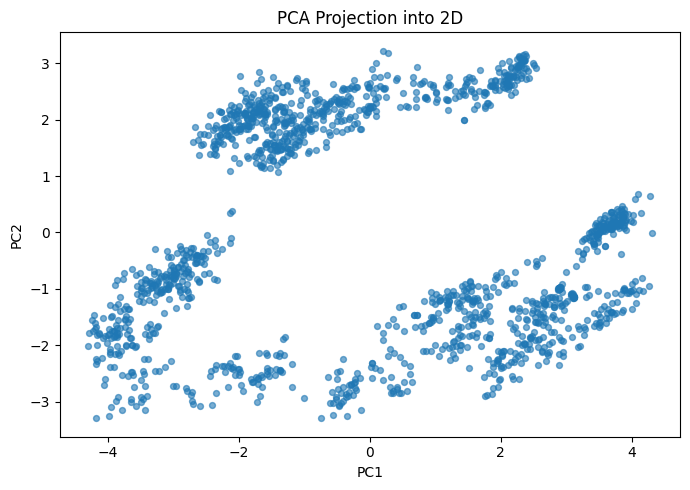

In [14]:
pca_projection_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "PC3": pca_components[:, 2],
})

plt.figure(figsize=(7, 5))
plt.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], alpha=0.6, s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection into 2D")
plt.tight_layout()
plt.show()


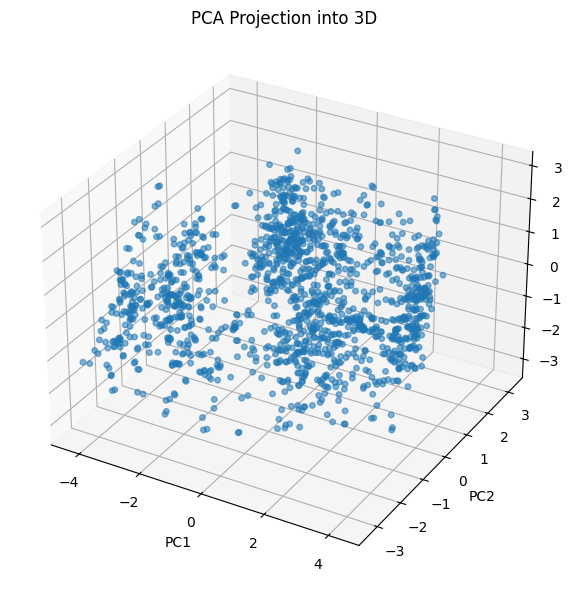

In [15]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], pca_projection_df["PC3"], alpha=0.55, s=16)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Projection into 3D")
plt.tight_layout()
plt.show()


In [16]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    index=MODEL_FEATURES,
    columns=[f"PC{i+1}" for i in range(len(MODEL_FEATURES))]
)

# Show the strongest absolute contributors to the first three principal components.
top_loading_rows = []
for component in ["PC1", "PC2", "PC3"]:
    top_features = loading_matrix[component].abs().sort_values(ascending=False).head(5).index
    for feature in top_features:
        top_loading_rows.append({
            "component": component,
            "feature": feature,
            "loading": round(float(loading_matrix.loc[feature, component]), 4),
            "absolute_loading": round(float(abs(loading_matrix.loc[feature, component])), 4),
        })

top_loading_df = pd.DataFrame(top_loading_rows)
display(top_loading_df)


,component,feature,loading,absolute_loading
0,PC1,pue,0.3955,0.3955
1,PC1,outdoor_air_temp,0.3716,0.3716
2,PC1,cooling_to_it_ratio,0.3637,0.3637
3,PC1,ere,0.3626,0.3626
4,PC1,cooling_kw,0.3591,0.3591
5,PC2,it_power_kw,0.4316,0.4316
6,PC2,total_facility_kw,0.3946,0.3946
7,PC2,minute_of_day,-0.3843,0.3843
8,PC2,hour_of_day,-0.3842,0.3842
9,PC2,plug_and_light_kw,-0.3215,0.3215


> **PCA interpretation box:** PCA is useful here because several variables carry overlapping information. A small number of principal components captures a large share of variance, which indicates redundancy in the original feature set. However, PCA projections may hide information: points close in 2D may still be far apart in the full feature space, and anomalies in discarded components can disappear visually.


## 7. Clustering Analysis on Samples

The notebook compares three clustering approaches:

- **K-Means:** centroid-based clustering that favors compact, roughly spherical clusters.
- **DBSCAN:** density-based clustering that can mark sparse points as noise and detect non-spherical clusters.
- **Hierarchical Clustering:** builds nested groupings based on distance between observations.

The goal is not to force beautiful clusters, but to examine whether the data contains meaningful structure and how sensitive the conclusions are to the algorithm.


In [17]:
def cluster_variance_ratio(X, labels):
    """Average within-cluster variance divided by global variance.
    Lower values indicate that clusters are internally tighter than the full dataset.
    Noise label -1 is ignored for DBSCAN.
    """
    labels = np.asarray(labels)
    valid_labels = [label for label in np.unique(labels) if label != -1]
    if len(valid_labels) == 0:
        return np.nan
    global_variance = float(np.var(X, axis=0).mean())
    weighted_variance_sum = 0.0
    valid_count = 0
    for label in valid_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            weighted_variance_sum += len(cluster_points) * float(np.var(cluster_points, axis=0).mean())
            valid_count += len(cluster_points)
    if valid_count == 0 or global_variance == 0:
        return np.nan
    return weighted_variance_sum / valid_count / global_variance


def safe_cluster_metrics(X, labels, method_name):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    usable_labels = labels[non_noise_mask]
    usable_X = X[non_noise_mask]
    number_of_clusters = len(set(usable_labels))
    number_of_noise = int((labels == -1).sum())
    if number_of_clusters >= 2 and len(usable_X) > number_of_clusters:
        silhouette = silhouette_score(usable_X, usable_labels)
        calinski = calinski_harabasz_score(usable_X, usable_labels)
        davies = davies_bouldin_score(usable_X, usable_labels)
    else:
        silhouette = np.nan
        calinski = np.nan
        davies = np.nan
    return {
        "method": method_name,
        "number_of_clusters_excluding_noise": number_of_clusters,
        "noise_points": number_of_noise,
        "silhouette_score": silhouette,
        "calinski_harabasz_score": calinski,
        "davies_bouldin_score": davies,
        "within_cluster_variance_ratio": cluster_variance_ratio(X, labels),
    }


In [18]:
# K-Means model selection check using silhouette score
kmeans_selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
    kmeans_selection_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "within_cluster_variance_ratio": cluster_variance_ratio(X_scaled, labels),
    })

kmeans_selection_df = pd.DataFrame(kmeans_selection_rows)
display(kmeans_selection_df)

selected_k = int(kmeans_selection_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Selected k for K-Means based on silhouette score:", selected_k)

kmeans_labels = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
analysis_df["kmeans_cluster"] = kmeans_labels

display(analysis_df["kmeans_cluster"].value_counts().sort_index().to_frame("count"))


,k,silhouette_score,within_cluster_variance_ratio
0,2,0.345764,0.634333
1,3,0.400650,0.426665
2,4,0.406525,0.337121
3,5,0.398189,0.271633
4,6,0.364931,0.246171


Selected k for K-Means based on silhouette score: 4


,count
kmeans_cluster,
0,540
1,404
2,375
3,181


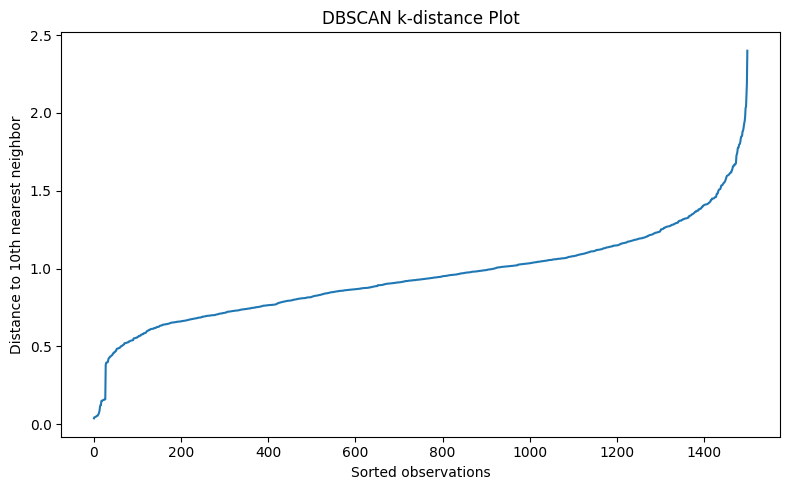

Chosen DBSCAN eps: 1.2146
Chosen DBSCAN min_samples: 10


,count
dbscan_cluster,
-1,45
0,757
1,122
2,576


In [19]:
# DBSCAN parameter selection using k-distance values.
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title("DBSCAN k-distance Plot")
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

# A quantile-based epsilon is used as a transparent heuristic rather than claiming an exact optimum.
dbscan_eps = float(np.quantile(k_distances, 0.85))
print("Chosen DBSCAN eps:", round(dbscan_eps, 4))
print("Chosen DBSCAN min_samples:", min_samples)

dbscan_labels = DBSCAN(eps=dbscan_eps, min_samples=min_samples).fit_predict(X_scaled)
analysis_df["dbscan_cluster"] = dbscan_labels

display(analysis_df["dbscan_cluster"].value_counts().sort_index().to_frame("count"))


In [20]:
hierarchical_cluster_count = selected_k
hierarchical_labels = AgglomerativeClustering(n_clusters=hierarchical_cluster_count, linkage="ward").fit_predict(X_scaled)
analysis_df["hierarchical_cluster"] = hierarchical_labels

display(analysis_df["hierarchical_cluster"].value_counts().sort_index().to_frame("count"))


,count
hierarchical_cluster,
0,514
1,443
2,401
3,142


In [21]:
cluster_metrics_df = pd.DataFrame([
    safe_cluster_metrics(X_scaled, kmeans_labels, "K-Means"),
    safe_cluster_metrics(X_scaled, dbscan_labels, "DBSCAN"),
    safe_cluster_metrics(X_scaled, hierarchical_labels, "Hierarchical"),
]).round(4)

display(cluster_metrics_df)


,method,number_of_clusters_excluding_noise,noise_points,silhouette_score,calinski_harabasz_score,davies_bouldin_score,within_cluster_variance_ratio
0,K-Means,4,0,0.4065,980.5261,0.8988,0.3371
1,DBSCAN,3,45,0.2573,443.8606,1.2512,0.6118
2,Hierarchical,4,0,0.4026,953.9903,0.8947,0.3433


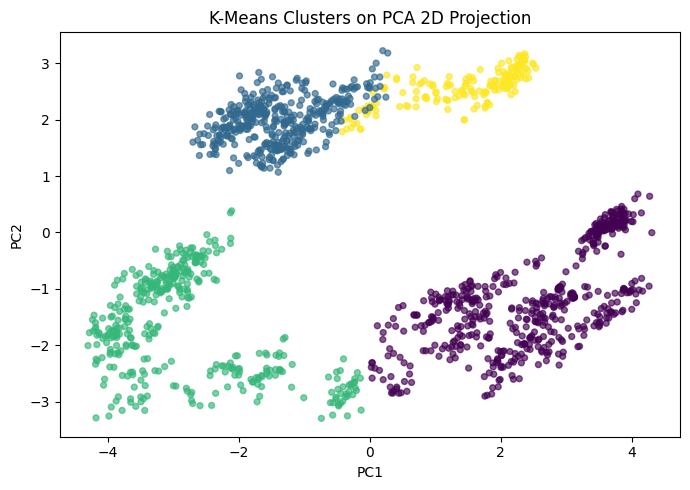

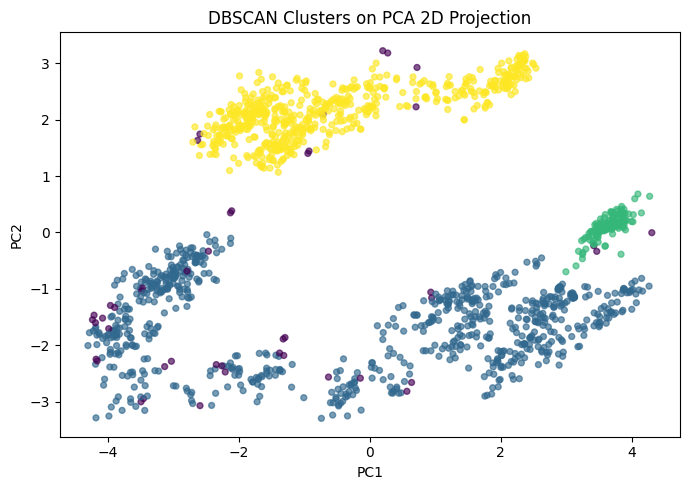

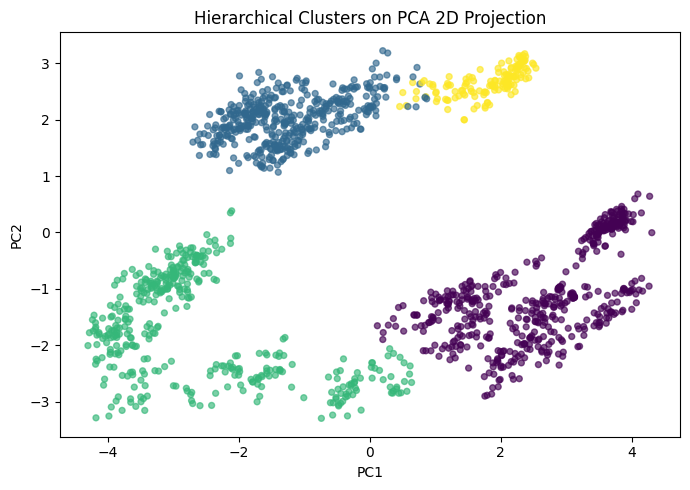

In [22]:
clustered_projection_df = pca_projection_df.copy()
clustered_projection_df["K-Means"] = kmeans_labels
clustered_projection_df["DBSCAN"] = dbscan_labels
clustered_projection_df["Hierarchical"] = hierarchical_labels

for method in ["K-Means", "DBSCAN", "Hierarchical"]:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        clustered_projection_df["PC1"],
        clustered_projection_df["PC2"],
        c=clustered_projection_df[method],
        alpha=0.65,
        s=18,
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{method} Clusters on PCA 2D Projection")
    plt.tight_layout()
    plt.show()


In [23]:
# Cluster profiles help translate clusters into real-world operating regimes.
cluster_profile = analysis_df.groupby("kmeans_cluster")[MODEL_FEATURES].mean().round(3)
display(cluster_profile)

relative_profile = (cluster_profile - analysis_df[MODEL_FEATURES].mean()) / analysis_df[MODEL_FEATURES].std()
display(relative_profile.round(2))


,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
kmeans_cluster,,,,,,,,,,,,,
0,14.715,0.990,9.075,904.818,6.070,1.046,11.500,49.311,78.601,18.989,1169.256,946.177,0.016
1,11.971,0.957,8.854,919.855,2.443,1.038,11.566,82.346,64.051,5.874,382.265,954.690,0.013
2,6.632,0.949,8.199,879.034,3.083,1.033,11.399,59.986,66.564,11.376,712.352,908.348,0.008
3,17.097,0.982,9.499,923.725,2.444,1.044,11.593,52.479,75.986,1.061,90.525,964.357,0.019


,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
kmeans_cluster,,,,,,,,,,,,,
0,0.58,0.91,0.26,0.01,1.00,1.00,-0.01,-0.81,0.99,1.12,1.12,0.22,0.55
1,-0.06,-0.58,0.01,0.77,-0.68,-0.41,0.19,1.43,-1.00,-0.81,-0.81,0.59,-0.10
2,-1.31,-0.95,-0.75,-1.30,-0.38,-1.29,-0.31,-0.09,-0.66,-0.00,-0.00,-1.44,-1.20
3,1.14,0.55,0.75,0.96,-0.68,0.65,0.27,-0.60,0.63,-1.52,-1.52,1.01,1.21


> **Clustering interpretation box:** K-Means and Hierarchical Clustering tend to partition all observations, while DBSCAN may classify sparse observations as noise. In this dataset, clusters are best interpreted as operating regimes rather than true ground-truth classes. For example, clusters may reflect lower-load periods, higher cooling demand, or changing outside weather. Differences between algorithms are expected because centroid-based, density-based, and hierarchical methods optimize different notions of similarity.


## 8. Feature-Space Clustering

The assignment also requires clustering the features themselves. This is done by transposing the standardized matrix so that each feature is represented by its behavior across all observations.

> **Feature-space clustering box:** Clustering features can reveal groups of related or redundant measurements. In data-center analysis, this may help identify groups such as cooling-related variables, IT-load variables, weather variables, and engineered ratio variables.


In [24]:
feature_vectors = X_scaled.T
feature_cluster_count = 4
feature_cluster_labels = AgglomerativeClustering(n_clusters=feature_cluster_count, linkage="ward").fit_predict(feature_vectors)

feature_cluster_df = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "feature_cluster": feature_cluster_labels,
}).sort_values(["feature_cluster", "feature"])

display(feature_cluster_df)


,feature,feature_cluster
7,outdoor_air_humidity,0
6,pump_kw,0
2,hvac_kw,1
3,it_power_kw,1
11,total_facility_kw,1
0,cooling_kw,2
12,cooling_to_it_ratio,2
1,ere,2
8,outdoor_air_temp,2
5,pue,2


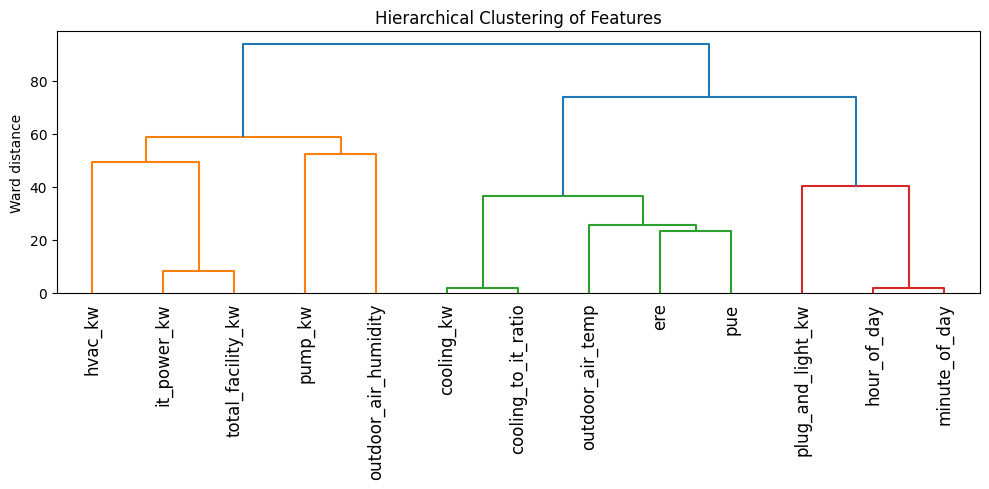

In [25]:
# Dendrogram of feature relationships
feature_linkage = linkage(feature_vectors, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(feature_linkage, labels=MODEL_FEATURES, leaf_rotation=90)
plt.title("Hierarchical Clustering of Features")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


> **Feature clustering interpretation box:** Feature-space clustering provides information that sample clustering does not directly show. It identifies which measurements behave similarly across time. Strong feature groups can indicate redundancy, while isolated features may represent unique operational behavior. This is useful in sensor, medical, financial, cybersecurity, and IoT domains where many measurements may contain overlapping information.


## 9. Multi-Dimensional Anomaly Detection

This is the main part of the assignment. Three methods are compared:

1. Classical Z-score method
2. Isolation Forest
3. Local Outlier Factor

The methods are applied to the standardized multi-feature space.


In [26]:
anomaly_results = pd.DataFrame(index=analysis_df.index)
anomaly_results["ts"] = raw_df.loc[analysis_df.index, "ts"] if "ts" in raw_df.columns else analysis_df.index
for feature in MODEL_FEATURES:
    anomaly_results[feature] = analysis_df[feature]

runtime_rows = []


### 9.1 Z-Score Method

The Z-score method flags observations that are far from the mean in standardized units. The classical rule is often based on values above about 3 standard deviations from the mean.

> **Z-score assumption box:** This method assumes that feature-wise deviations from the mean are meaningful, which is strongest when distributions are approximately Gaussian. It may fail in high dimensions because an observation can be moderately unusual in many variables without crossing a single feature threshold.


In [27]:
start_time = time.perf_counter()
absolute_z_scores = np.abs(X_scaled)
z_score_threshold = 3.0
z_score_anomaly = (absolute_z_scores > z_score_threshold).any(axis=1)
z_score_runtime = time.perf_counter() - start_time

anomaly_results["z_score_anomaly"] = z_score_anomaly
anomaly_results["max_abs_z_score"] = absolute_z_scores.max(axis=1)
anomaly_results["number_of_extreme_features"] = (absolute_z_scores > z_score_threshold).sum(axis=1)

runtime_rows.append({"method": "Z-Score", "runtime_seconds": z_score_runtime})

print("Z-score threshold:", z_score_threshold)
print("Z-score anomalies:", int(z_score_anomaly.sum()))
print("Z-score anomaly percentage:", round(z_score_anomaly.mean() * 100, 2))

display(
    anomaly_results.sort_values("max_abs_z_score", ascending=False)
    .head(10)[["ts", "max_abs_z_score", "number_of_extreme_features"] + MODEL_FEATURES]
)


Z-score threshold: 3.0
Z-score anomalies: 12
Z-score anomaly percentage: 0.8


,ts,max_abs_z_score,number_of_extreme_features,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
268,2016-07-28 13:13:20+00:00,3.609353,1,5.47,0.921,5.71,872.99,3.18,1.029,11.02,49.8,70.7,13,793,898.37,0.006266
267,2016-07-28 13:12:21+00:00,3.494318,1,5.47,0.910,5.81,871.02,3.16,1.029,11.02,49.6,70.6,13,792,896.48,0.006280
270,2016-07-28 13:15:25+00:00,3.298758,1,6.37,0.937,5.98,871.85,3.13,1.030,11.02,49.4,70.8,13,795,898.35,0.007306
139,2016-07-28 11:04:23+00:00,3.297932,1,5.77,0.897,10.01,878.92,2.44,1.034,11.33,68.5,61.6,11,664,908.47,0.006565
269,2016-07-28 13:14:23+00:00,3.264248,1,6.37,0.928,6.01,872.82,3.16,1.030,11.02,50.0,70.7,13,794,899.38,0.007298
213,2016-07-28 12:18:20+00:00,3.252697,1,6.67,0.898,8.01,878.80,2.46,1.032,10.92,67.1,62.4,12,738,906.86,0.007590
212,2016-07-28 12:17:21+00:00,3.207462,1,6.67,0.899,7.53,878.06,2.46,1.032,11.52,67.5,62.4,12,737,906.24,0.007596
211,2016-07-28 12:16:22+00:00,3.071757,1,6.67,0.902,7.41,877.32,2.41,1.032,11.43,68.3,62.4,12,736,905.24,0.007603
291,2016-07-28 13:36:22+00:00,3.068688,1,6.97,0.953,6.18,874.99,3.68,1.032,11.12,49.8,71.3,13,816,902.94,0.007966
292,2016-07-28 13:37:22+00:00,3.034177,1,6.97,0.955,6.21,873.63,3.68,1.032,11.12,49.7,71.3,13,817,901.61,0.007978


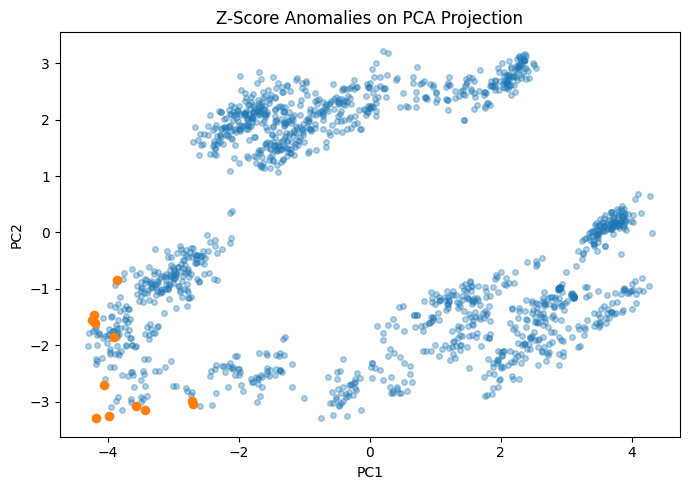

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], alpha=0.35, s=16)
plt.scatter(pca_projection_df.loc[z_score_anomaly, "PC1"], pca_projection_df.loc[z_score_anomaly, "PC2"], s=35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Z-Score Anomalies on PCA Projection")
plt.tight_layout()
plt.show()


### 9.2 Isolation Forest

Isolation Forest identifies anomalies by randomly partitioning feature space. Observations that are easier to isolate with short paths in random trees receive stronger anomaly scores.

> **Isolation Forest box:** The contamination parameter controls the expected fraction of observations flagged as anomalous. A higher contamination value increases sensitivity and false alarms; a lower value is more conservative. Because the dataset has no true anomaly label, contamination is a modeling assumption rather than a known fact.


In [29]:
start_time = time.perf_counter()
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=RANDOM_STATE,
)
isolation_labels = isolation_forest.fit_predict(X_scaled)
isolation_runtime = time.perf_counter() - start_time

isolation_anomaly = isolation_labels == -1
# decision_function: lower values are more anomalous. We multiply by -1 to make larger values more anomalous.
isolation_anomaly_score = -isolation_forest.decision_function(X_scaled)

anomaly_results["isolation_forest_anomaly"] = isolation_anomaly
anomaly_results["isolation_forest_score"] = isolation_anomaly_score

runtime_rows.append({"method": "Isolation Forest", "runtime_seconds": isolation_runtime})

print("Isolation Forest contamination:", 0.05)
print("Isolation Forest anomalies:", int(isolation_anomaly.sum()))
print("Isolation Forest anomaly percentage:", round(isolation_anomaly.mean() * 100, 2))

display(
    anomaly_results.sort_values("isolation_forest_score", ascending=False)
    .head(10)[["ts", "isolation_forest_score", "max_abs_z_score"] + MODEL_FEATURES]
)


Isolation Forest contamination: 0.05
Isolation Forest anomalies: 75
Isolation Forest anomaly percentage: 5.0


,ts,isolation_forest_score,max_abs_z_score,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
267,2016-07-28 13:12:21+00:00,0.061522,3.494318,5.47,0.910,5.81,871.02,3.16,1.029,11.02,49.6,70.6,13,792,896.48,0.006280
265,2016-07-28 13:10:23+00:00,0.048741,2.804107,5.27,0.925,6.41,870.34,3.11,1.030,11.12,49.6,70.4,13,790,896.25,0.006055
266,2016-07-28 13:11:21+00:00,0.048435,2.919142,5.17,0.914,6.31,872.72,3.16,1.030,11.12,49.2,70.4,13,791,898.48,0.005924
268,2016-07-28 13:13:20+00:00,0.044084,3.609353,5.47,0.921,5.71,872.99,3.18,1.029,11.02,49.8,70.7,13,793,898.37,0.006266
259,2016-07-28 13:04:21+00:00,0.043708,2.608547,5.47,0.917,6.58,873.07,3.59,1.031,11.22,47.2,69.7,13,784,899.93,0.006265
261,2016-07-28 13:06:22+00:00,0.039775,2.804107,5.47,0.916,6.41,871.86,3.11,1.030,11.42,49.2,69.9,13,786,898.27,0.006274
260,2016-07-28 13:05:24+00:00,0.038038,2.574036,5.47,0.914,6.61,871.03,3.13,1.030,11.22,49.0,69.8,13,785,897.46,0.006280
256,2016-07-28 13:01:22+00:00,0.035963,2.339284,6.17,0.919,6.91,874.82,3.61,1.031,10.72,46.7,68.8,13,781,902.23,0.007053
255,2016-07-28 13:00:23+00:00,0.030119,2.339284,6.17,0.921,6.98,875.50,3.59,1.031,10.72,47.0,68.5,13,780,902.96,0.007047
262,2016-07-28 13:07:22+00:00,0.029627,2.919142,5.47,0.926,6.31,872.73,3.16,1.030,11.42,48.4,70.1,13,787,899.09,0.006268


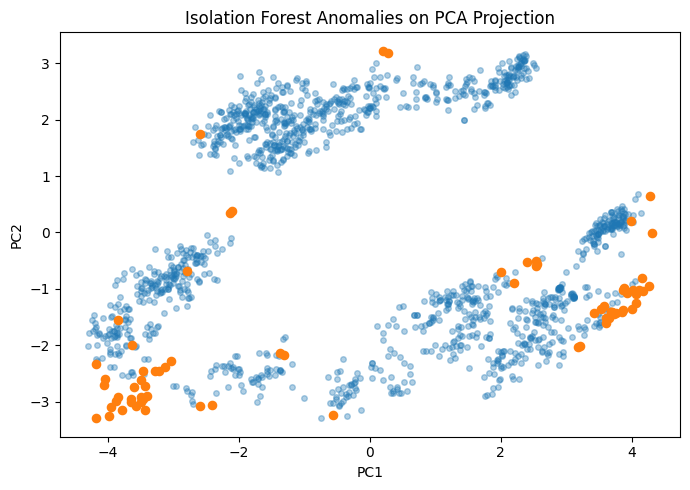

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], alpha=0.35, s=16)
plt.scatter(pca_projection_df.loc[isolation_anomaly, "PC1"], pca_projection_df.loc[isolation_anomaly, "PC2"], s=35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies on PCA Projection")
plt.tight_layout()
plt.show()


### 9.3 Local Outlier Factor (LOF)

LOF compares the local density around each observation with the local density around its neighbors. A point can be anomalous if it lies in a sparse region relative to nearby points.

> **LOF box:** LOF is useful for local anomalies that may not look extreme globally. However, it is sensitive to the number of neighbors `k`, feature scaling, and local density variation. In this notebook `n_neighbors=20` is used as a balanced choice for a 1,500-row sample.


In [31]:
start_time = time.perf_counter()
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof_model.fit_predict(X_scaled)
lof_runtime = time.perf_counter() - start_time

lof_anomaly = lof_labels == -1
# negative_outlier_factor_: more negative means more anomalous. Multiply by -1 so higher means more anomalous.
lof_score = -lof_model.negative_outlier_factor_

anomaly_results["lof_anomaly"] = lof_anomaly
anomaly_results["lof_score"] = lof_score

runtime_rows.append({"method": "LOF", "runtime_seconds": lof_runtime})

print("LOF n_neighbors:", 20)
print("LOF contamination:", 0.05)
print("LOF anomalies:", int(lof_anomaly.sum()))
print("LOF anomaly percentage:", round(lof_anomaly.mean() * 100, 2))

display(
    anomaly_results.sort_values("lof_score", ascending=False)
    .head(10)[["ts", "lof_score", "max_abs_z_score"] + MODEL_FEATURES]
)


LOF n_neighbors: 20
LOF contamination: 0.05
LOF anomalies: 75
LOF anomaly percentage: 5.0


,ts,lof_score,max_abs_z_score,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
802,2016-07-28 22:07:21+00:00,2.371435,1.559318,18.27,0.999,9.09,931.96,5.52,1.048,11.82,44.5,81.8,22,1327,976.66,0.019604
829,2016-07-28 22:34:21+00:00,2.080584,2.936096,19.27,0.992,8.99,927.74,2.44,1.044,10.52,46.1,80.8,22,1354,968.96,0.020771
830,2016-07-28 22:35:22+00:00,2.074377,2.936096,19.27,0.993,8.99,925.17,2.46,1.045,10.52,46.1,80.8,22,1355,966.41,0.020829
41,2016-07-28 09:26:24+00:00,1.801867,2.786606,7.37,0.930,11.27,887.86,2.44,1.037,12.12,66.2,65.7,9,566,921.06,0.008301
42,2016-07-28 09:27:22+00:00,1.791071,2.786606,7.27,0.931,11.27,887.16,2.44,1.037,12.12,66.5,65.7,9,567,920.26,0.008195
145,2016-07-28 11:10:23+00:00,1.768630,2.752095,5.27,0.947,11.24,885.65,2.46,1.034,10.82,67.9,61.6,11,670,915.44,0.005950
146,2016-07-28 11:11:21+00:00,1.662876,2.717585,5.27,0.956,11.21,884.70,2.44,1.035,11.72,67.8,61.6,11,671,915.34,0.005957
841,2016-07-28 22:46:21+00:00,1.652486,2.733618,18.67,0.988,8.89,922.27,2.44,1.046,12.42,46.2,81.5,22,1366,964.69,0.020244
877,2016-07-28 23:22:21+00:00,1.602322,2.733618,19.17,0.994,9.42,928.71,2.44,1.047,12.42,47.3,81.2,23,1402,972.16,0.020642
790,2016-07-28 21:55:22+00:00,1.539061,1.473606,18.17,0.991,8.59,911.12,2.44,1.044,11.32,44.2,81.9,21,1315,951.64,0.019942


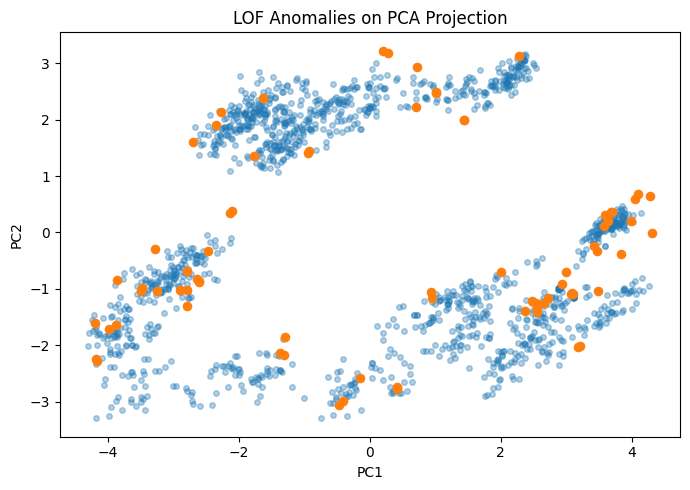

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], alpha=0.35, s=16)
plt.scatter(pca_projection_df.loc[lof_anomaly, "PC1"], pca_projection_df.loc[lof_anomaly, "PC2"], s=35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LOF Anomalies on PCA Projection")
plt.tight_layout()
plt.show()


## 10. Anomaly Method Agreement and Comparison

The following section compares which observations were flagged by one, two, or three anomaly methods.


In [33]:
anomaly_flag_columns = ["z_score_anomaly", "isolation_forest_anomaly", "lof_anomaly"]
anomaly_results["anomaly_vote_count"] = anomaly_results[anomaly_flag_columns].sum(axis=1)

agreement_summary = anomaly_results["anomaly_vote_count"].value_counts().sort_index().to_frame("number_of_observations")
agreement_summary["percentage"] = (agreement_summary["number_of_observations"] / len(anomaly_results) * 100).round(2)
display(agreement_summary)

method_counts = pd.DataFrame({
    "method": ["Z-Score", "Isolation Forest", "LOF"],
    "anomaly_count": [z_score_anomaly.sum(), isolation_anomaly.sum(), lof_anomaly.sum()],
    "anomaly_percentage": [z_score_anomaly.mean() * 100, isolation_anomaly.mean() * 100, lof_anomaly.mean() * 100],
}).round(2)

display(method_counts)

runtime_df = pd.DataFrame(runtime_rows).round(5)
display(runtime_df)


,number_of_observations,percentage
anomaly_vote_count,,
0,1358,90.53
1,122,8.13
2,20,1.33


,method,anomaly_count,anomaly_percentage
0,Z-Score,12,0.8
1,Isolation Forest,75,5.0
2,LOF,75,5.0


,method,runtime_seconds
0,Z-Score,0.00060
1,Isolation Forest,0.63599
2,LOF,0.03860


In [34]:
# Show observations flagged by at least two methods.
consensus_anomalies = anomaly_results[anomaly_results["anomaly_vote_count"] >= 2].copy()
consensus_anomalies = consensus_anomalies.sort_values(
    ["anomaly_vote_count", "isolation_forest_score", "lof_score", "max_abs_z_score"],
    ascending=False
)

print("Consensus anomalies detected by at least two methods:", len(consensus_anomalies))
display(consensus_anomalies.head(15)[["ts", "anomaly_vote_count", "max_abs_z_score", "isolation_forest_score", "lof_score"] + MODEL_FEATURES])


Consensus anomalies detected by at least two methods: 20


,ts,anomaly_vote_count,max_abs_z_score,isolation_forest_score,lof_score,cooling_kw,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_humidity,outdoor_air_temp,hour_of_day,minute_of_day,total_facility_kw,cooling_to_it_ratio
267,2016-07-28 13:12:21+00:00,2,3.494318,0.061522,1.189140,5.47,0.910,5.81,871.02,3.16,1.029,11.02,49.6,70.6,13,792,896.48,0.006280
268,2016-07-28 13:13:20+00:00,2,3.609353,0.044084,1.131440,5.47,0.921,5.71,872.99,3.18,1.029,11.02,49.8,70.7,13,793,898.37,0.006266
240,2016-07-28 12:45:24+00:00,2,3.034177,0.021409,0.996773,5.07,0.945,6.21,873.28,2.46,1.029,11.22,54.7,64.0,12,765,898.24,0.005806
269,2016-07-28 13:14:23+00:00,2,3.264248,0.020736,1.020899,6.37,0.928,6.01,872.82,3.16,1.030,11.02,50.0,70.7,13,794,899.38,0.007298
270,2016-07-28 13:15:25+00:00,2,3.298758,0.020177,1.027388,6.37,0.937,5.98,871.85,3.13,1.030,11.02,49.4,70.8,13,795,898.35,0.007306
612,2016-07-28 18:57:22+00:00,2,1.883273,0.012373,1.335477,18.87,1.000,8.49,880.63,6.60,1.051,10.92,48.6,78.8,18,1137,925.51,0.021428
331,2016-07-28 14:16:23+00:00,2,2.136806,0.010710,1.439882,6.57,0.968,9.02,871.03,3.18,1.036,12.22,45.2,74.2,14,856,902.02,0.007543
611,2016-07-28 18:56:23+00:00,2,1.883273,0.010374,1.320735,18.87,1.000,8.56,880.66,6.64,1.051,10.92,48.3,78.8,18,1136,925.65,0.021427
41,2016-07-28 09:26:24+00:00,2,2.786606,0.010040,1.801867,7.37,0.930,11.27,887.86,2.44,1.037,12.12,66.2,65.7,9,566,921.06,0.008301
145,2016-07-28 11:10:23+00:00,2,2.752095,0.009451,1.768630,5.27,0.947,11.24,885.65,2.46,1.034,10.82,67.9,61.6,11,670,915.44,0.005950


In [35]:
# Compare feature means between normal observations and consensus anomalies.
anomaly_results["consensus_anomaly"] = anomaly_results["anomaly_vote_count"] >= 2
comparison_profile = anomaly_results.groupby("consensus_anomaly")[MODEL_FEATURES].mean().T
comparison_profile.columns = ["not_consensus_anomaly", "consensus_anomaly"] if True in comparison_profile.columns else comparison_profile.columns
comparison_profile["difference"] = comparison_profile.iloc[:, -1] - comparison_profile.iloc[:, 0]
display(comparison_profile.round(4))


,not_consensus_anomaly,consensus_anomaly,difference
cooling_kw,12.2645,10.6200,-1.6445
ere,0.9701,0.9550,-0.0152
hvac_kw,8.8477,8.8375,-0.0102
it_power_kw,904.8963,890.4360,-14.4603
plug_and_light_kw,3.9139,3.5275,-0.3864
pue,1.0403,1.0386,-0.0017
pump_kw,11.5039,11.5055,0.0016
outdoor_air_humidity,61.3211,56.6800,-4.6411
outdoor_air_temp,71.3649,70.7900,-0.5749
hour_of_day,11.3622,13.4500,2.0878


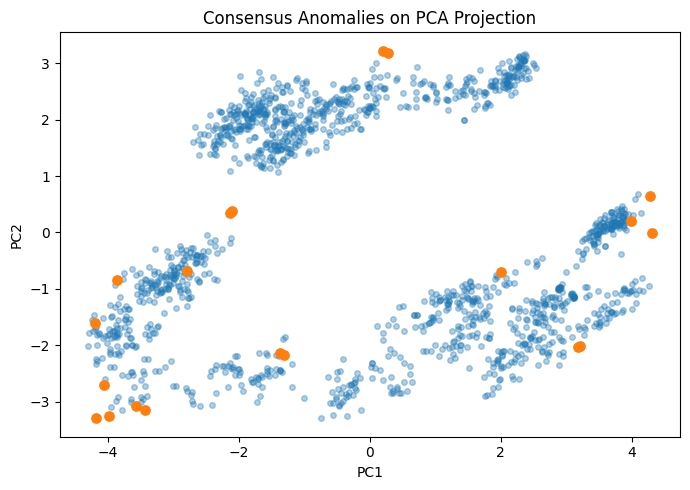

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(pca_projection_df["PC1"], pca_projection_df["PC2"], alpha=0.35, s=16)
consensus_mask = anomaly_results["consensus_anomaly"].values
plt.scatter(pca_projection_df.loc[consensus_mask, "PC1"], pca_projection_df.loc[consensus_mask, "PC2"], s=45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Consensus Anomalies on PCA Projection")
plt.tight_layout()
plt.show()


> **Anomaly comparison box:** Agreement between methods is more convincing than a single method, but disagreement is also informative. Z-score tends to find feature-wise extreme values. Isolation Forest finds points that are easy to isolate through random partitions. LOF finds points in locally sparse neighborhoods. Therefore, method-specific anomalies are expected and do not automatically mean that one method is wrong.

> **False positive / false negative box:** In this dataset, a false positive would mean flagging a legitimate operating state as anomalous, possibly causing unnecessary inspection. A false negative would mean missing a real unusual state, such as inefficient cooling or a sensor issue. Since no verified anomaly labels exist, these errors cannot be counted directly; they must be interpreted operationally.


## 11. Sensitivity Analysis

This section compares sensitivity to scaling and dimensionality. Distance-based methods usually depend strongly on scaling, and high-dimensional spaces can reduce the meaning of distances.


In [37]:
# Scaling sensitivity: compare K-Means on scaled and unscaled data.
kmeans_unscaled = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE).fit_predict(analysis_df[MODEL_FEATURES])

scaling_sensitivity = pd.DataFrame([
    {
        "setting": "scaled_features",
        "silhouette_score": silhouette_score(X_scaled, kmeans_labels),
        "within_cluster_variance_ratio": cluster_variance_ratio(X_scaled, kmeans_labels),
    },
    {
        "setting": "unscaled_features",
        "silhouette_score": silhouette_score(analysis_df[MODEL_FEATURES], kmeans_unscaled),
        "within_cluster_variance_ratio": cluster_variance_ratio(analysis_df[MODEL_FEATURES].to_numpy(), kmeans_unscaled),
    }
]).round(4)

display(scaling_sensitivity)


,setting,silhouette_score,within_cluster_variance_ratio
0,scaled_features,0.4065,0.3371
1,unscaled_features,0.5688,0.0659


In [38]:
# Dimensionality sensitivity: run anomaly methods on all scaled features vs first PCA components explaining at least 90% variance.
n_components_90 = components_for_90
X_pca_90 = pca_components[:, :n_components_90]

iso_pca = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE).fit(X_pca_90)
iso_pca_anomaly = iso_pca.predict(X_pca_90) == -1

lof_pca = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pca_anomaly = lof_pca.fit_predict(X_pca_90) == -1

sensitivity_df = pd.DataFrame({
    "method": ["Isolation Forest", "LOF"],
    "full_feature_anomaly_count": [isolation_anomaly.sum(), lof_anomaly.sum()],
    "pca_90_anomaly_count": [iso_pca_anomaly.sum(), lof_pca_anomaly.sum()],
    "agreement_with_full_features": [
        np.mean(iso_pca_anomaly == isolation_anomaly),
        np.mean(lof_pca_anomaly == lof_anomaly),
    ],
}).round(4)

display(sensitivity_df)


,method,full_feature_anomaly_count,pca_90_anomaly_count,agreement_with_full_features
0,Isolation Forest,75,75,0.9267
1,LOF,75,75,0.9653


> **Sensitivity interpretation box:** The same dataset can produce different clusters or anomaly flags depending on scaling, number of retained dimensions, contamination rate, neighborhood size, and distance metric. This is why unsupervised conclusions should be treated as evidence for investigation, not as definitive labels.


## 12. Final Visualization Dashboard

This notebook section acts as a compact visual dashboard with PCA, clustering, anomaly, pairwise, and heatmap views.


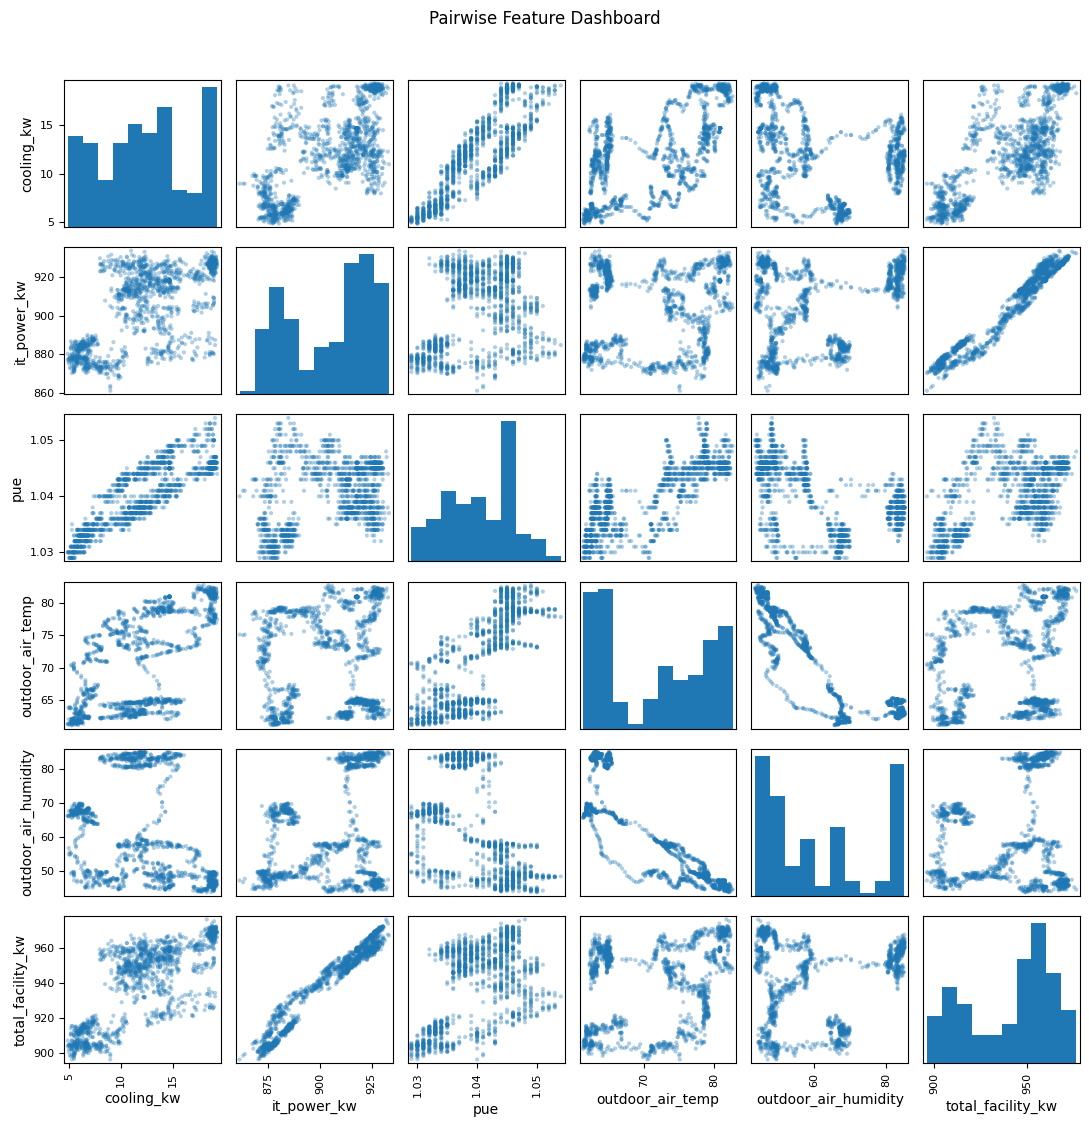

In [39]:
# Pairwise dashboard for a focused subset of features.
dashboard_features = [
    "cooling_kw",
    "it_power_kw",
    "pue",
    "outdoor_air_temp",
    "outdoor_air_humidity",
    "total_facility_kw",
]

scatter_matrix(analysis_df[dashboard_features], figsize=(11, 11), diagonal="hist", alpha=0.35)
plt.suptitle("Pairwise Feature Dashboard", y=1.02)
plt.tight_layout()
plt.show()


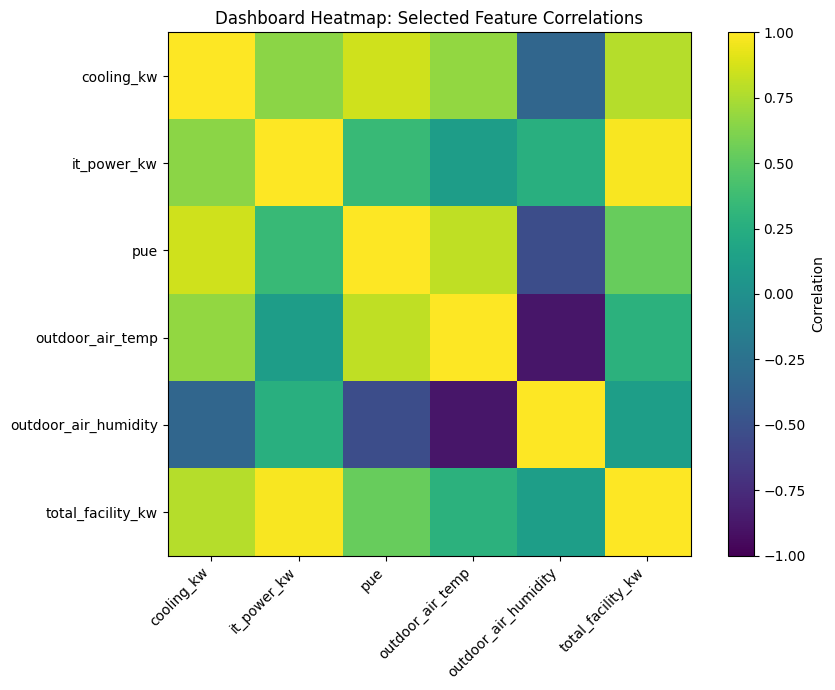

In [40]:
plt.figure(figsize=(9, 7))
small_corr = analysis_df[dashboard_features].corr()
plt.imshow(small_corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(dashboard_features)), dashboard_features, rotation=45, ha="right")
plt.yticks(range(len(dashboard_features)), dashboard_features)
plt.title("Dashboard Heatmap: Selected Feature Correlations")
plt.tight_layout()
plt.show()


## 13. Critical Analysis and Ethical Reflection

> **Critical reflection box:** Anomaly detection is fundamentally ill-defined because the dataset does not provide a true anomaly label. An algorithm can identify observations that are rare, sparse, distant, or easy to isolate, but this does not prove that they are operational failures. In a data-center context, a flagged point may represent an inefficient cooling state, a sensor artifact, a short peak-load event, or a normal but rare operating regime.

> **Curse of dimensionality box:** As dimensionality increases, distances between points can become less informative. Many distance-based methods, including K-Means, DBSCAN, and LOF, may become sensitive to irrelevant or redundant features. PCA can reduce redundancy, but it may also hide anomalies that exist in lower-variance directions.

> **Gaussian assumption box:** Z-score methods assume that feature-wise deviations from the mean are meaningful. If a feature is skewed, heavy-tailed, bounded, or multi-modal, Gaussian-based thresholds may incorrectly flag normal extremes or miss structured anomalies.

> **Noise versus genuine anomaly box:** A high cooling value can be a true unusual event, but it can also be a legitimate response to high IT load or outside weather. Conversely, a sensor spike may appear anomalous but have no operational meaning. The notebook therefore treats anomalies as investigation candidates rather than confirmed failures.

> **Ethical considerations box:** False alarms can make anomaly systems ineffective because operators may begin ignoring alerts. In cybersecurity, missing a real attack can be severe, but flagging legitimate behavior as malicious can disrupt normal work. In medical settings, incorrectly labeling a patient as anomalous or normal may affect care. In surveillance or human-behavior contexts, labeling people or behavior as abnormal raises privacy, fairness, and bias concerns. Even though this dataset is engineering-oriented, the same caution applies: anomaly detection should support human review rather than replace it.


## 14. Final Conclusions

> **Final conclusion box:** The data-center dataset satisfies the assignment requirements and supports meaningful unsupervised analysis. PCA shows that the feature set contains redundancy, especially among power and efficiency-related variables. Clustering reveals possible operating regimes, but the separation is not absolute and should not be interpreted as ground truth. Feature-space clustering reveals groups of related measurements that are not obvious from sample clustering alone. Anomaly detection methods identify different but partially overlapping unusual observations, reflecting their different assumptions: Z-score focuses on feature-wise extremes, Isolation Forest focuses on isolation through random partitioning, and LOF focuses on local density. The most reliable observations for further engineering investigation are those flagged by multiple methods, but even these should be validated with domain knowledge and operational context.
